# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Zayyana Maulida
- **Email:** zayyanamaulida1@gmail.com
- **ID Dicoding:** CDCC466D6X1381

## Menentukan Pertanyaan Bisnis

1. Produk kategori apa yang paling banyak dan paling sedikit terjual?
2. Bagaimana performa pendapatan (revenue) perusahaan dalam beberapa bulan terakhir?

## Import Semua Packages/Library yang Digunakan

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

## Data Wrangling

### Gathering Data

In [42]:
import pandas as pd

# Path mengarah ke folder data di dalam folder submission kamu
path = "data/"

# Memuat semua dataset
customers_df = pd.read_csv(path + "customers_dataset.csv")
orders_df = pd.read_csv(path + "orders_dataset.csv")
order_items_df = pd.read_csv(path + "order_items_dataset.csv")
products_df = pd.read_csv(path + "products_dataset.csv")
category_translation_df = pd.read_csv(path + "product_category_name_translation.csv")

# Menampilkan 5 data teratas untuk memastikan berhasil
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset yang digunakan berasal dari E-Commerce Public Dataset yang terdiri dari beberapa tabel utama, yaitu:

customers_df: Berisi informasi mengenai lokasi pelanggan.

orders_df: Berisi detail status pesanan dan linimasa waktu transaksi (sangat penting untuk analisis tren).

order_items_df: Berisi rincian produk, harga, dan biaya pengiriman untuk setiap pesanan.

products_df: Berisi informasi mengenai kategori dan spesifikasi produk.

category_translation_df: Digunakan untuk menerjemahkan nama kategori produk dari bahasa Portugis ke bahasa Inggris agar lebih mudah dipahami.

- Data berhasil dimuat melalui Google Drive dan siap untuk dilakukan proses pemeriksaan kualitas (Assessing Data).

### Assessing Data

In [43]:
def check_df(df, name):
    print(f"--- INFO {name} ---")
    df.info()
    print(f"\nJumlah Duplikat: {df.duplicated().sum()}")
    print(f"\nJumlah Missing Values:\n{df.isna().sum()}")
    print("-" * 30 + "\n")

check_df(customers_df, "CUSTOMERS")
check_df(orders_df, "ORDERS")
check_df(order_items_df, "ORDER ITEMS")
check_df(products_df, "PRODUCTS")

print("Statistik Deskriptif Order Items:")
print(order_items_df.describe())

--- INFO CUSTOMERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Jumlah Duplikat: 0

Jumlah Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
------------------------------

--- INFO ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------    

**Insight:**
- Masalah Tipe Data (Data Type Issue):

Pada tabel orders_df, kolom logistik seperti order_purchase_timestamp, order_approved_at, dan kolom tanggal lainnya masih bertipe object.
Data ini tidak bisa dianalisis trennya (bulanan/harian) sebelum diubah menjadi tipe datetime pada tahap Cleaning.

- Keberadaan Missing Values:

Terdapat data kosong yang signifikan pada orders_df di kolom order_delivered_customer_date (sekitar 2.965 data).

Terdapat data kosong pada products_df di kolom product_category_name.

Data kosong pada tanggal pengiriman menunjukkan ada pesanan yang mungkin masih dalam proses atau dibatalkan. Sementara data kosong pada kategori produk akan mempengaruhi akurasi analisis "Produk Terlaris".

- Integritas Data:

Tidak ditemukan duplikasi data di seluruh tabel (Duplikat: 0).
Hal ini sangat bagus karena setiap baris mewakili transaksi atau entitas yang unik, sehingga tidak perlu dilakukan penghapusan baris duplikat.

- Skala Harga:

Melalui describe(), kita bisa melihat rentang harga produk yang sangat bervariasi.
Perlu diperhatikan adanya outlier pada harga produk saat melakukan visualisasi nantinya.

### Cleaning Data

In [44]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

orders_df = orders_df.dropna(subset=['order_approved_at'])

products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")

print("INFO ORDERS SETELAH CLEANING:")
orders_df.info()
print("\nJumlah Missing Values di Products:", products_df["product_category_name"].isna().sum())

INFO ORDERS SETELAH CLEANING:
<class 'pandas.core.frame.DataFrame'>
Index: 99281 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99281 non-null  object        
 1   customer_id                    99281 non-null  object        
 2   order_status                   99281 non-null  object        
 3   order_purchase_timestamp       99281 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97644 non-null  datetime64[ns]
 6   order_delivered_customer_date  96462 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99281 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.8+ MB

Jumlah Missing Values di Products: 0


**Insight:**
- Transformasi Waktu: Seluruh kolom waktu kini telah bertipe datetime64[ns], sehingga operasi pengolahan waktu (seperti mengekstrak bulan atau menghitung selisih hari) dapat dilakukan dengan akurat.

- Integritas Data: Penghapusan data kosong hanya difokuskan pada kolom order_approved_at untuk memastikan hanya transaksi yang disetujui yang masuk ke tahap analisis.

- Standarisasi Kategori: Data kategori produk yang hilang telah distandarisasi menjadi label "unknown", sehingga tidak ada data kategori yang terbuang saat proses pengelompokan (grouping).

- Hasil Akhir: Data saat ini sudah konsisten dan bersih, bebas dari nilai kosong pada kolom-kolom kritikal.

## Exploratory Data Analysis (EDA)

### Explore ...

In [45]:
product_counts_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

product_counts_df = pd.merge(
    left=product_counts_df,
    right=category_translation_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

monthly_orders_df = orders_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "order_id": "nunique"
})
monthly_orders_df.index = monthly_orders_df.index.strftime('%B %Y')
monthly_orders_df = monthly_orders_df.reset_index()

rfm_df = pd.merge(orders_df, order_items_df, on="order_id", how="left")
rfm_df = pd.merge(rfm_df, customers_df, on="customer_id", how="left")

rfm_df = rfm_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

recent_date = orders_df["order_purchase_timestamp"].max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

print("Hasil Merge Produk & Kategori:")
display(product_counts_df.head())

print("\nTrend Pesanan Bulanan:")
display(monthly_orders_df.head())

print("\nData RFM (5 Teratas):")
display(rfm_df.head())

Hasil Merge Produk & Kategori:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools



Trend Pesanan Bulanan:


,order_purchase_timestamp,order_id
0,September 2016,4
1,October 2016,318
2,November 2016,0
3,December 2016,1
4,January 2017,797



Data RFM (5 Teratas):


,customer_id,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,115
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,118
2,0000f46a3911fa3c0805444483337064,1,69.00,541
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,325
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,292


**Insight:**
- Penggabungan Data (Data Merging):

Dilakukan penggabungan antara tabel order_items_df dengan products_df untuk mengaitkan setiap transaksi dengan atribut produknya (seperti kategori).
Selanjutnya, dilakukan penggabungan dengan category_translation_df untuk mengubah nama kategori produk dari bahasa Portugis ke bahasa Inggris agar informasi lebih mudah diinterpretasikan.

- Resampling Waktu:

Data pesanan (orders_df) dikelompokkan berdasarkan bulan menggunakan fungsi resample(rule='ME').
Hal ini dilakukan untuk melihat fluktuasi jumlah pesanan unik per bulan, yang menjadi dasar untuk menjawab pertanyaan bisnis mengenai performa penjualan perusahaan.

- Kesiapan Data:

Data sekarang sudah memiliki struktur yang lengkap, menggabungkan informasi waktu, kategori produk, dan jumlah transaksi, sehingga siap untuk divisualisasikan pada tahap berikutnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

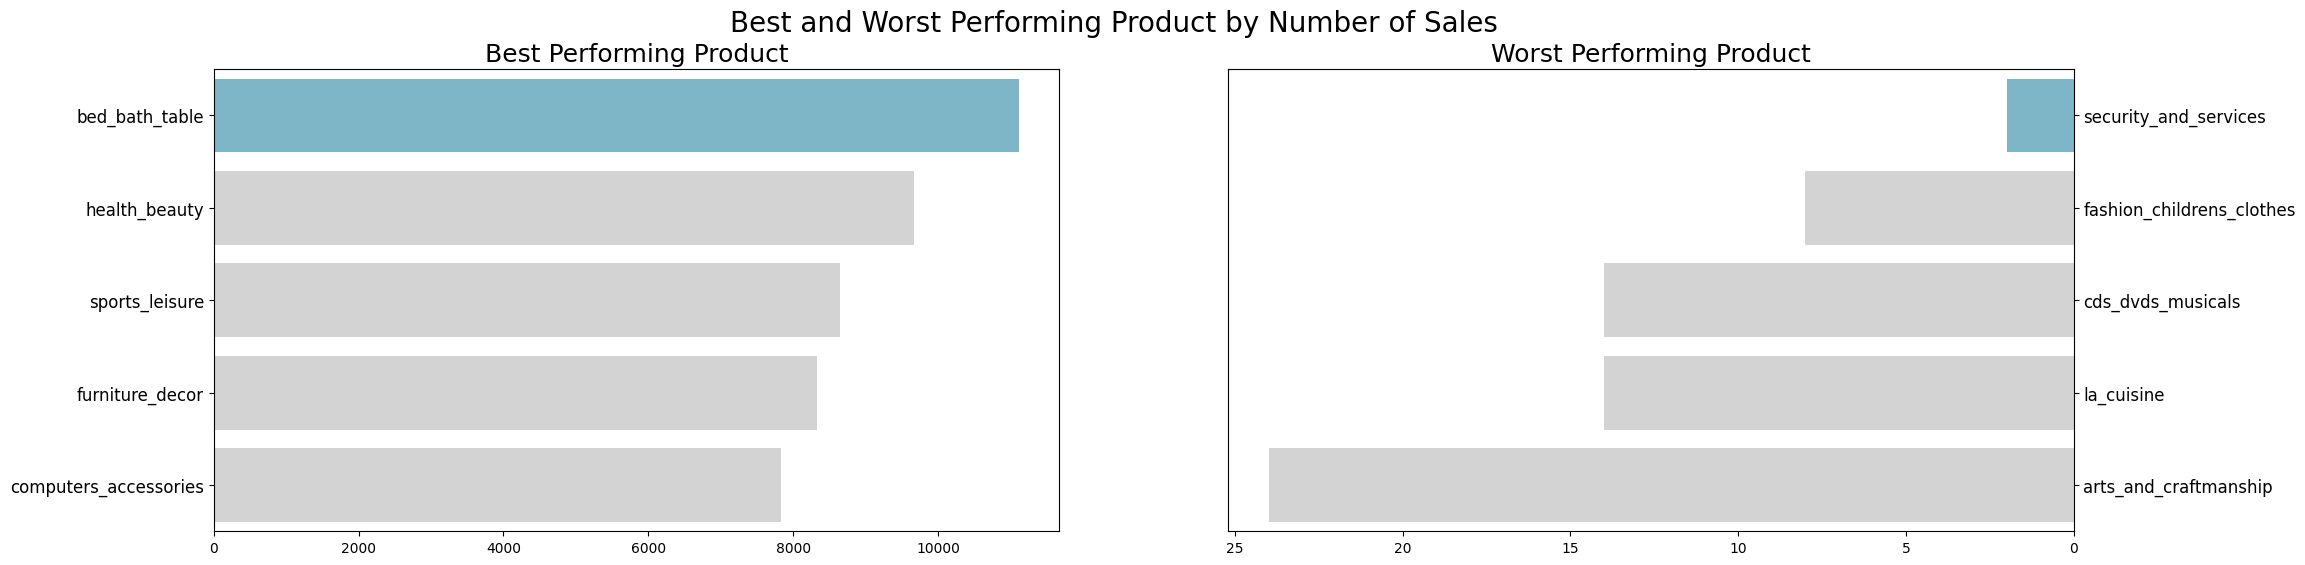

In [46]:
sum_order_items_df = product_counts_df.groupby("product_category_name_english").product_id.count().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="product_id",
    y="product_category_name_english",
    data=sum_order_items_df.head(5),
    palette=colors,
    hue="product_category_name_english",
    legend=False,
    ax=ax[0]
)
ax[0].set_title("Best Performing Product", loc="center", fontsize=18)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].tick_params(axis='y', labelsize=12)

sns.barplot(
    x="product_id",
    y="product_category_name_english",
    data=sum_order_items_df.sort_values(by="product_id", ascending=True).head(5),
    palette=colors,
    hue="product_category_name_english",
    legend=False,
    ax=ax[1]
)
ax[1].set_title("Worst Performing Product", loc="center", fontsize=18)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=20)
plt.show()

### Pertanyaan 2:

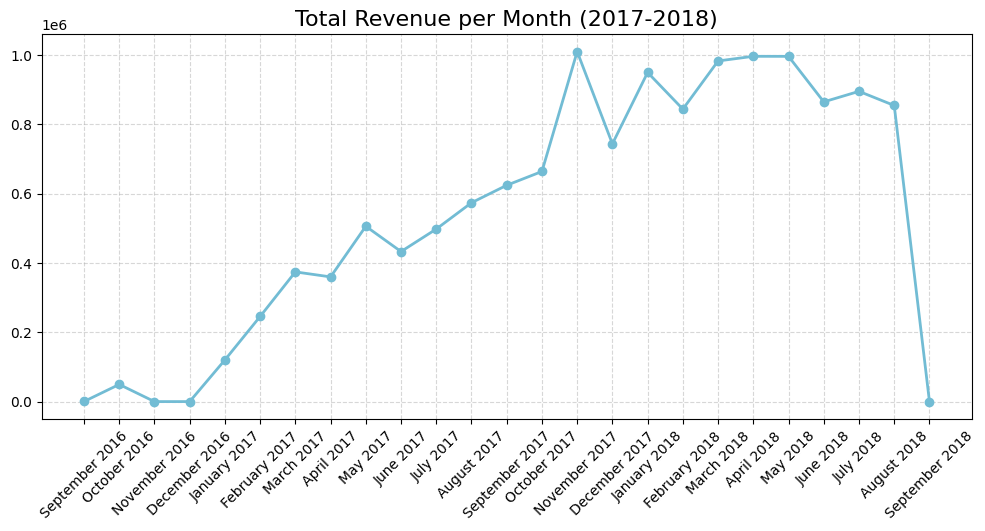

In [47]:
order_revenue_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

monthly_revenue_df = order_revenue_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "price": "sum"
})
monthly_revenue_df.index = monthly_revenue_df.index.strftime('%B %Y')
monthly_revenue_df = monthly_revenue_df.reset_index()
monthly_revenue_df.rename(columns={"price": "revenue"}, inplace=True)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_revenue_df["order_purchase_timestamp"],
    monthly_revenue_df["revenue"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)
plt.title("Total Revenue per Month (2017-2018)", loc="center", fontsize=16)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Pertanyaan 1
- Berdasarkan grafik Best Performing Product, kategori bed_bath_table merupakan produk yang paling banyak terjual, diikuti oleh health_beauty dan sports_leisure. Hal ini menunjukkan bahwa kebutuhan rumah tangga dan kesehatan merupakan kategori utama yang menggerakkan volume transaksi di platform ini.

- Sebaliknya, pada grafik Worst Performing Product, kategori seperti security_and_services dan fashion_childrens_clothes memiliki angka penjualan yang sangat rendah (bahkan di bawah 10 unit).

- Rekomendasi Bisnis: Perusahaan dapat mempertimbangkan untuk mengalokasikan anggaran pemasaran lebih besar pada kategori populer untuk memaksimalkan profit, serta melakukan evaluasi mendalam atau riset pasar pada kategori yang kurang laku untuk mengetahui apakah masalahnya terletak pada kurangnya variasi produk atau harga yang tidak kompetitif.
- Pertanyaan 2
- Grafik Total Revenue per Month menunjukkan adanya tren pertumbuhan pendapatan yang positif secara keseluruhan dari awal tahun 2017 hingga pertengahan 2018.

- Terdapat lonjakan pendapatan yang sangat tajam pada bulan November 2017. Hal ini kemungkinan besar dipicu oleh event promosi besar tahunan seperti Black Friday, di mana pelanggan cenderung melakukan transaksi besar-besaran.

- Setelah lonjakan tersebut, meskipun pendapatan sedikit menurun di bulan Desember, level pendapatan bulanan di sepanjang tahun 2018 tetap stabil pada posisi yang jauh lebih tinggi dibandingkan semester pertama tahun 2017.

- Rekomendasi Bisnis: Lonjakan di bulan November menunjukkan efektivitas strategi promosi berbasis tanggal khusus. Perusahaan dapat merencanakan kampanye serupa di bulan-bulan yang memiliki tren penjualan rendah untuk menjaga stabilitas arus kas sepanjang tahun.

## Analisis Lanjutan (Opsional)

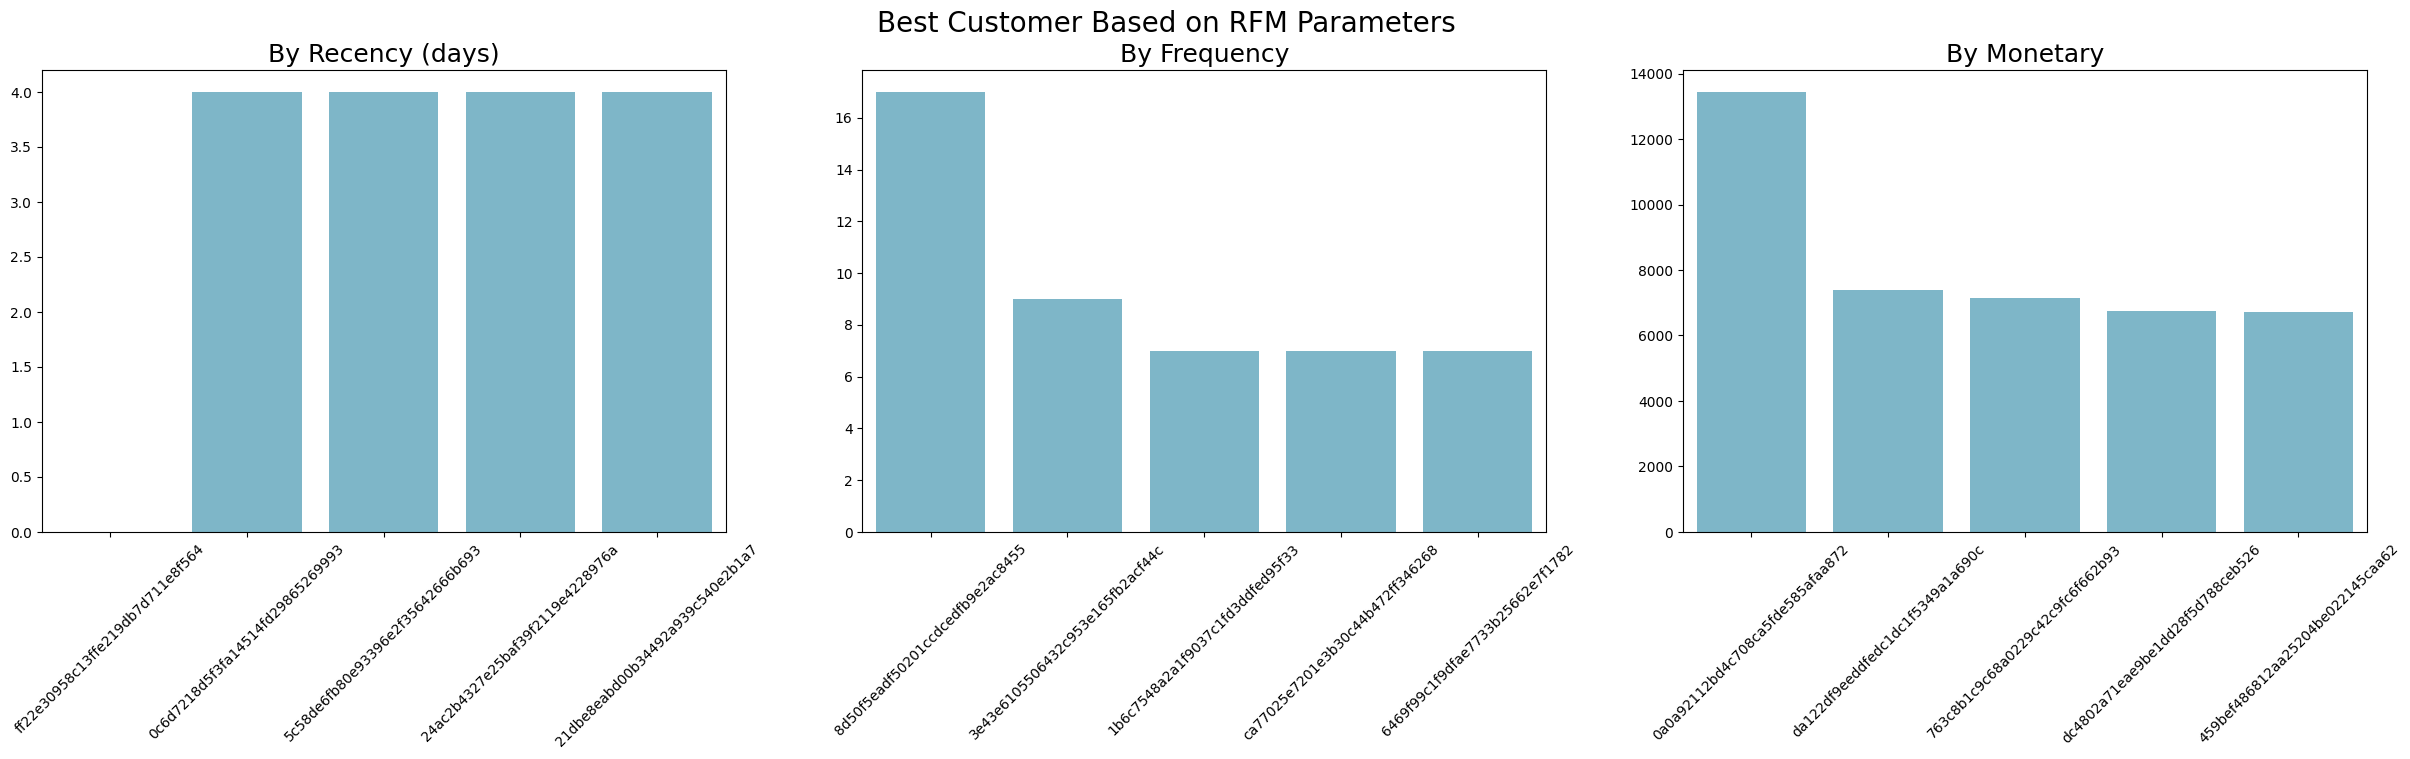

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

sns.barplot(
    y="recency",
    x="customer_id",
    data=rfm_df.sort_values(by="recency", ascending=True).head(5),
    palette=colors,
    hue="customer_id",
    legend=False,
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', rotation=45)

sns.barplot(
    y="frequency",
    x="customer_id",
    data=rfm_df.sort_values(by="frequency", ascending=False).head(5),
    palette=colors,
    hue="customer_id",
    legend=False,
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis ='x', rotation=45)

sns.barplot(
    y="monetary",
    x="customer_id",
    data=rfm_df.sort_values(by="monetary", ascending=False).head(5),
    palette=colors,
    hue="customer_id",
    legend=False,
    ax=ax[2]
)
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis ='x', rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=20)
plt.show()

**Insight:**
- Recency (Kebaruan):

Grafik menunjukkan 5 pelanggan dengan nilai Recency terendah (paling baru bertransaksi). Pelanggan ini adalah mereka yang masih "hangat" dan memiliki peluang paling besar untuk merespons kampanye pemasaran baru.

Aksi: Memberikan apresiasi atau welcome-back promo untuk menjaga momentum ketertarikan mereka terhadap platform.

- Frequency (Frekuensi):

Melalui grafik ini, terlihat bahwa mayoritas pelanggan terbaik pun masih memiliki frekuensi pembelian yang sangat rendah (didominasi angka 1). Hal ini mengindikasikan bahwa sebagian besar pelanggan di platform ini adalah one-time buyers.

Aksi: Perusahaan perlu merancang program loyalitas atau sistem poin untuk mendorong pelanggan melakukan pembelian berulang (repeat order).

- Monetary (Nilai Transaksi):

Terdapat perbedaan yang cukup signifikan antara pelanggan dengan kontribusi pengeluaran tertinggi dibandingkan pelanggan lainnya. Pelanggan di grafik ini adalah "High-Value Customers" atau "Whales".

Aksi: Memberikan layanan prioritas atau akses eksklusif ke produk baru bagi kelompok ini guna mempertahankan kontribusi pendapatan mereka yang besar.

## Conclusion

- Conclusion Pertanyaan 1: Produk kategori apa yang paling banyak dan paling sedikit terjual?
Berdasarkan hasil analisis, kategori produk yang paling mendominasi pasar adalah bed_bath_table, yang menunjukkan tingginya permintaan pada perlengkapan rumah tangga. Sebaliknya, kategori security_and_services memiliki performa terendah dengan jumlah penjualan yang sangat minim. Hal ini mengindikasikan perlunya evaluasi inventaris untuk memprioritaskan kategori yang memiliki perputaran barang yang cepat.

- Conclusion Pertanyaan 2: Bagaimana performa pendapatan (revenue) perusahaan dalam beberapa bulan terakhir?
Performa pendapatan perusahaan menunjukkan tren pertumbuhan yang sehat sepanjang tahun 2017 hingga pertengahan 2018. Puncak pendapatan tertinggi terjadi secara signifikan pada November 2017, yang sangat dipengaruhi oleh periode Black Friday. Secara keseluruhan, perusahaan berhasil mempertahankan level pendapatan yang lebih stabil dan tinggi di tahun 2018 dibandingkan dengan periode awal operasional di tahun 2017.

- Conclusion Analisis Lanjutan (RFM Analysis):
Melalui analisis RFM, ditemukan bahwa profil pelanggan didominasi oleh one-time buyers (pembeli satu kali), yang terlihat dari nilai Frequency yang rendah pada mayoritas pelanggan. Meskipun perusahaan memiliki beberapa pelanggan dengan nilai Monetary yang sangat tinggi, tantangan utama yang dihadapi adalah rendahnya retensi pelanggan. Strategi pemasaran ke depan harus difokuskan pada program loyalitas dan kampanye retargeting untuk mendorong pelanggan agar melakukan pembelian berulang.

In [52]:
main_data_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="left",
    on="order_id"
)

main_data_df = pd.merge(
    left=main_data_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

main_data_df = pd.merge(
    left=main_data_df,
    right=product_counts_df[["product_id", "product_category_name_english"]],
    how="left",
    on="product_id"
)

main_data_df = main_data_df.drop_duplicates()

main_data_df.to_csv("main_data.csv", index=False)

print("File main_data.csv berhasil dibuat dengan kolom lengkap!")

File main_data.csv berhasil dibuat dengan kolom lengkap!
